# Trabajo Práctico N.° 4 — Clasificando informales en la EPH
## Métodos de regularización y CART

**Universidad de Buenos Aires — Taller de Programación — 2026**  
**Grupo 7 — Asalariados informales lower-tier**  
**Integrantes:** Antony Araujo y Erick Huamanchumo

### Objetivo
El trabajo busca predecir la informalidad laboral *lower-tier* en 2025 mediante:

- Regresión logística sin penalización.
- Regresión logística con penalización **LASSO (L1)**.
- Regresión logística con penalización **Ridge (L2)**.
- Árbol de decisión podado **CART**.

Se utiliza la muestra longitudinal de personas observadas tanto en 2024 como en 2025 y se incorpora la condición de informalidad de 2024 (`informal_2024`) como predictor, siguiendo la extensión de Maurizio & Monsalvo (2021).


## 0. Preparación del entorno

En esta primera parte se cargan las librerías necesarias y se prepara Google Colab para recibir la base de datos desde la computadora.  
Es preciso mencionar que script incluye código para que los resultados del trabajo se vayan guardando en carpetas de tablas y figuras para poder descargarlos al final.

In [ ]:
# ============================================================
# 0. LIBRERÍAS Y CONFIGURACIÓN
# ============================================================

import os
import sys
import warnings
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    cross_val_predict
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 123

# Carpeta de trabajo temporal en Google Colab
BASE = Path("/content/TP4_Grupo7")
FIG = BASE / "resultados" / "figuras"
TAB = BASE / "resultados" / "tablas"

for carpeta in [FIG, TAB]:
    carpeta.mkdir(parents=True, exist_ok=True)

print("Entorno preparado correctamente.")
print("Carpeta de trabajo:", BASE)

Entorno preparado correctamente.
Carpeta de trabajo: /content/TP4_Grupo7


## 1. Carga de la base de datos

El archivo utilizado es `EPH_base_final_2024T4_2025T4.xlsx`.


In [ ]:
# ============================================================
# CARGA DE LA BASE DESDE LA COMPUTADORA
# ============================================================

EN_COLAB = "google.colab" in sys.modules

if EN_COLAB:
    from google.colab import files
    print("Seleccione el archivo: EPH_base_final_2024T4_2025T4.xlsx")
    uploaded = files.upload()

    archivos_excel = [
        nombre for nombre in uploaded.keys()
        if nombre.lower().endswith((".xlsx", ".xls"))
    ]

    if len(archivos_excel) == 0:
        raise FileNotFoundError("No se cargó ningún archivo Excel.")

    archivo = archivos_excel[0]

else:
    # Ruta alternativa para ejecución fuera de Colab.
    archivo = "/mnt/data/EPH_base_final_2024T4_2025T4.xlsx"

print("Archivo seleccionado:", archivo)

# La hoja base_final_ocupados contiene las variables creadas en los TP previos.
base = pd.read_excel(
    archivo,
    sheet_name="base_final_ocupados"
)

print("Dimensión de la base:", base.shape)
display(base.head())

Seleccione el archivo: EPH_base_final_2024T4_2025T4.xlsx


Saving EPH_base_final_2024T4_2025T4.xlsx to EPH_base_final_2024T4_2025T4.xlsx
Archivo seleccionado: EPH_base_final_2024T4_2025T4.xlsx
Dimensión de la base: (40830, 57)


,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,...,P47T_NOMINAL,FACTOR_ACTUALIZACION_2025T4,UNIDAD_INGRESOS,condicion_asalariada,lower_tier_informal,edad2,CH14_LIMPIO,educ,horas_totales_ocupado,horastrab
0,TQRMNOSQTHMKLQCDEHPJB00872830,2024,4,1,1,1,40,S,29,380,...,1000000.0,1.314106,Pesos constantes del 4T 2025,Formal,0.0,900,NaN,15.0,70,70.0
1,TQRMNOSQTHMKLQCDEHPJB00872830,2024,4,1,2,1,40,S,29,380,...,500000.0,1.314106,Pesos constantes del 4T 2025,Formal,0.0,900,NaN,15.0,30,NaN
2,TQRMNOPYTHLMKOCDEIHJF00854747,2024,4,1,1,1,44,N,31,226,...,2500000.0,1.314106,Pesos constantes del 4T 2025,Formal,0.0,1936,3.0,14.0,49,49.0
3,TQRMNOPYTHLMKOCDEIHJF00854747,2024,4,1,2,1,44,N,31,226,...,2100000.0,1.314106,Pesos constantes del 4T 2025,Formal,0.0,2116,NaN,19.0,40,NaN
4,TQRMNOQQSHKKPPCDEIJAH00872831,2024,4,1,1,1,1,S,33,2049,...,900000.0,1.314106,Pesos constantes del 4T 2025,Formal,0.0,1296,NaN,17.0,32,32.0


## 2. Construcción de la muestra longitudinal 2025-MM

De acuerdo a la consigna se solicita trabajar con `ocupados_X_2025_MM` y `y_2025`, incorporando como predictor el estado de informalidad observado en 2024.

Por lo cual para evitar fuga de información:

- La variable objetivo de 2025 es `lower_tier_informal`.
- Se excluyen variables que forman parte directa de la definición de informalidad, como `PP07H`, `sin_descuento_jubilatorio`, `PP04C` y `establecimiento_hasta_5`.
- Se identifica a una misma persona utilizando `CODUSU`, `NRO_HOGAR` y `COMPONENTE`.
- Se conservan únicamente casos con una clasificación válida de informalidad en ambos períodos.

In [ ]:
# ============================================================
# CONSTRUCCIÓN DE LA MUESTRA LONGITUDINAL
# ============================================================

# Solo observaciones con objetivo definido.
clasificados = base[base["lower_tier_informal"].notna()].copy()

ids = ["CODUSU", "NRO_HOGAR", "COMPONENTE"]

# Informalidad observada en 2024.
lag_2024 = (
    clasificados.loc[
        clasificados["ANO4"].eq(2024),
        ids + ["lower_tier_informal"]
    ]
    .rename(columns={"lower_tier_informal": "informal_2024"})
)

# Personas clasificables observadas en 2025.
base_2025 = clasificados[
    clasificados["ANO4"].eq(2025)
].copy()

# Inner join: misma persona observada en ambos años.
mm = base_2025.merge(
    lag_2024,
    on=ids,
    how="inner",
    validate="one_to_one"
)

mm["lower_tier_informal"] = mm["lower_tier_informal"].astype(int)
mm["informal_2024"] = mm["informal_2024"].astype(int)

print(f"Observaciones longitudinales: {len(mm):,}")
print(
    f"Informales lower-tier en 2025: "
    f"{mm['lower_tier_informal'].sum():,} "
    f"({100*mm['lower_tier_informal'].mean():.2f}%)"
)
print(
    f"Informales lower-tier en 2024 dentro de la muestra longitudinal: "
    f"{100*mm['informal_2024'].mean():.2f}%"
)

Observaciones longitudinales: 3,013
Informales lower-tier en 2025: 413 (13.71%)
Informales lower-tier en 2024 dentro de la muestra longitudinal: 14.21%


### Comentario:

La muestra longitudinal conserva aproximadamente **3 013 personas** observadas en ambos períodos. Alrededor del **13.7 %** se encuentra en condición informal *lower-tier* en 2025. Esto confirma que la clase positiva es minoritaria, por lo que no conviene evaluar los modelos únicamente con `accuracy`: también será necesario observar sensibilidad, precisión, F1 y ROC-AUC.

## 3. Matriz de predictores

La consigna solicita utilizar **más de 15 variables** y agregar el rezago de informalidad de 2024.

Para lo cual se utilizan características sociodemográficas, laborales y regionales. Asimismo, las variables categóricas (`REGION`, `MAS_500` y `CH03`) se convierten en variables binarias mediante *dummies*.

Los ingresos se expresan en millones de pesos, la edad al cuadrado se divide por 100 y las horas se expresan en decenas para facilitar la lectura de los coeficientes.

In [ ]:
# ============================================================
# MATRIZ X / Y
# ============================================================

variables_base = [
    # Características personales y del hogar
    "es_mujer",
    "vive_en_pareja",
    "tiene_cobertura_medica",
    "asiste_actualmente",
    "secundario_completo_o_mas",
    "CH06",
    "edad2",
    "educ",
    "nhogar",
    "CH03",

    # Características laborales
    "es_subocupado",
    "horas_totales_ocupado",
    "P21",
    "P47T",

    # Dimensión geográfica
    "REGION",
    "MAS_500",

    # Persistencia de informalidad
    "informal_2024"
]

X = mm[variables_base].copy()
y = mm["lower_tier_informal"].copy()

# Reescalamiento para facilitar interpretación numérica.
X["edad2"] = X["edad2"] / 100
X["horas_totales_ocupado"] = X["horas_totales_ocupado"] / 10
X["P21"] = X["P21"] / 1_000_000
X["P47T"] = X["P47T"] / 1_000_000

# Dummies de variables categóricas.
X = pd.get_dummies(
    X,
    columns=["REGION", "MAS_500", "CH03"],
    drop_first=True,
    dtype=float
)

# Imputación simple con la mediana para valores faltantes.
for columna in X.columns:
    if X[columna].isna().any():
        X[columna] = X[columna].fillna(X[columna].median())

print("Número final de predictores:", X.shape[1])
print("Número de observaciones:", X.shape[0])

display(
    pd.DataFrame({
        "Variable": X.columns
    })
)

Número final de predictores: 28
Número de observaciones: 3013


,Variable
0,es_mujer
1,vive_en_pareja
2,tiene_cobertura_medica
3,asiste_actualmente
4,secundario_completo_o_mas
5,CH06
6,edad2
7,educ
8,nhogar
9,es_subocupado


> Con la base adjunta se obtienen **28 predictores finales** después de crear las variables dummy. Esto cumple con la exigencia de trabajar con más de 15 características y, además, incorpora la variable `informal_2024`.

# Parte A. Regresión logística con regularización: Ridge y LASSO

## A.1. Trayectorias de coeficientes para distintos valores de λ


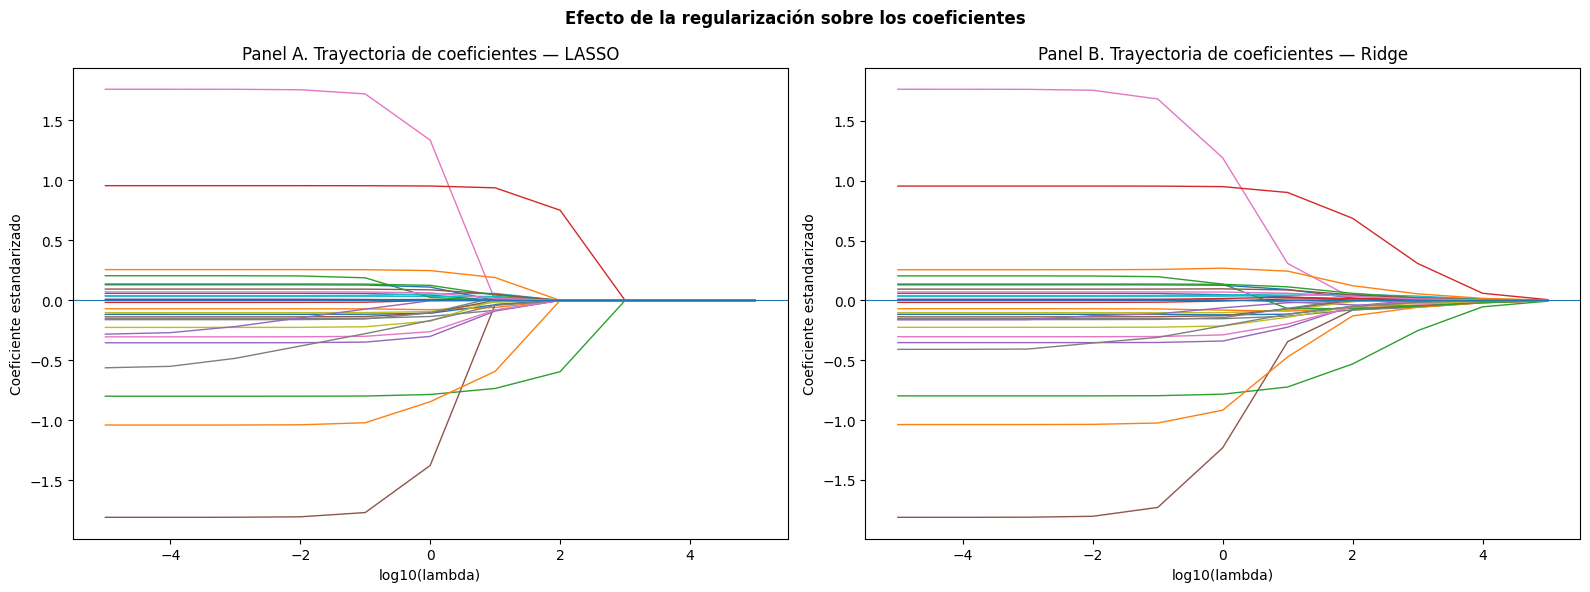

In [ ]:
# ============================================================
# A.1. TRAYECTORIAS DE COEFICIENTES LASSO Y RIDGE
# ============================================================

lambdas = 10.0 ** np.arange(-5, 6)
Cs = 1 / lambdas

# Estandarización previa para que la penalización sea comparable
# entre variables con distintas escalas.
scaler_path = StandardScaler()
X_std = scaler_path.fit_transform(X)

coef_paths = {
    "LASSO": [],
    "Ridge": []
}

for lam, C in zip(lambdas, Cs):

    # LASSO - penalidad L1
    modelo_l1 = LogisticRegression(
        penalty="l1",
        C=C,
        solver="liblinear",
        max_iter=5000,
        random_state=RANDOM_STATE
    )
    modelo_l1.fit(X_std, y)
    coef_paths["LASSO"].append(modelo_l1.coef_[0])

    # Ridge - penalidad L2
    modelo_l2 = LogisticRegression(
        penalty="l2",
        C=C,
        solver="liblinear",
        max_iter=5000,
        random_state=RANDOM_STATE
    )
    modelo_l2.fit(X_std, y)
    coef_paths["Ridge"].append(modelo_l2.coef_[0])

coef_lasso = np.array(coef_paths["LASSO"])
coef_ridge = np.array(coef_paths["Ridge"])

# Gráfico en dos paneles solicitado por la consigna.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for j, variable in enumerate(X.columns):
    axes[0].plot(
        np.log10(lambdas),
        coef_lasso[:, j],
        linewidth=1
    )

axes[0].axhline(0, linewidth=0.8)
axes[0].set_title("Panel A. Trayectoria de coeficientes — LASSO")
axes[0].set_xlabel("log10(lambda)")
axes[0].set_ylabel("Coeficiente estandarizado")

for j, variable in enumerate(X.columns):
    axes[1].plot(
        np.log10(lambdas),
        coef_ridge[:, j],
        linewidth=1
    )

axes[1].axhline(0, linewidth=0.8)
axes[1].set_title("Panel B. Trayectoria de coeficientes — Ridge")
axes[1].set_xlabel("log10(lambda)")
axes[1].set_ylabel("Coeficiente estandarizado")

fig.suptitle(
    "Efecto de la regularización sobre los coeficientes",
    fontweight="bold"
)

fig.tight_layout()
fig.savefig(
    FIG / "A1_trayectorias_coeficientes.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()

In [ ]:
# Comentario sobre del inciso A.1:

ceros_lasso_fuerte = np.sum(
    np.isclose(coef_lasso[-1], 0, atol=1e-8)
)

print("INTERPRETACIÓN A.1")
print("-" * 70)
print(
    "A medida que lambda aumenta, la penalización se vuelve más fuerte "
    "y los coeficientes se acercan a cero."
)
print(
    f"En LASSO, con la penalización más fuerte de la grilla, "
    f"{ceros_lasso_fuerte} de {X.shape[1]} coeficientes quedan exactamente "
    "en cero o prácticamente en cero. Esto muestra que LASSO también funciona "
    "como un método de selección de variables."
)
print(
    "En Ridge los coeficientes también se reducen, pero normalmente no se "
    "vuelven exactamente cero. Por eso Ridge conserva todas las variables, "
    "aunque reduce la influencia de las menos informativas."
)

INTERPRETACIÓN A.1
----------------------------------------------------------------------
A medida que lambda aumenta, la penalización se vuelve más fuerte y los coeficientes se acercan a cero.
En LASSO, con la penalización más fuerte de la grilla, 28 de 28 coeficientes quedan exactamente en cero o prácticamente en cero. Esto muestra que LASSO también funciona como un método de selección de variables.
En Ridge los coeficientes también se reducen, pero normalmente no se vuelven exactamente cero. Por eso Ridge conserva todas las variables, aunque reduce la influencia de las menos informativas.


## A.2. Selección de λ óptimo mediante 5-fold Cross-Validation

Se divide la muestra en cinco partes. En cada iteración:

1. Cuatro partes se utilizan para estimar el modelo.
2. La parte restante se utiliza para validar.
3. Se calcula el error de clasificación.
4. El procedimiento se repite para cada valor de λ.

Además de usar `LogisticRegressionCV`, se almacena el error de cada fold para construir los box-plots solicitados.

In [ ]:
# ============================================================
# A.2. CROSS-VALIDATION PARA LASSO Y RIDGE
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

errores_cv = []

for penalidad, nombre in [("l1", "LASSO"), ("l2", "Ridge")]:

    for lam, C in zip(lambdas, Cs):

        modelo = Pipeline([
            ("scaler", StandardScaler()),
            ("logit", LogisticRegression(
                penalty=penalidad,
                C=C,
                solver="liblinear",
                max_iter=5000,
                random_state=RANDOM_STATE
            ))
        ])

        accuracy_folds = cross_val_score(
            modelo,
            X,
            y,
            cv=cv,
            scoring="accuracy"
        )

        for fold, accuracy in enumerate(accuracy_folds, start=1):
            errores_cv.append({
                "Modelo": nombre,
                "lambda": lam,
                "C": C,
                "Fold": fold,
                "Error_clasificacion": 1 - accuracy
            })

errores_cv = pd.DataFrame(errores_cv)

# LogisticRegressionCV
cv_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegressionCV(
        Cs=Cs,
        cv=cv,
        penalty="l1",
        solver="liblinear",
        scoring="accuracy",
        max_iter=5000,
        refit=True,
        random_state=RANDOM_STATE
    ))
])

cv_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegressionCV(
        Cs=Cs,
        cv=cv,
        penalty="l2",
        solver="liblinear",
        scoring="accuracy",
        max_iter=5000,
        refit=True,
        random_state=RANDOM_STATE
    ))
])

cv_lasso.fit(X, y)
cv_ridge.fit(X, y)

C_lasso = float(cv_lasso.named_steps["logit"].C_[0])
C_ridge = float(cv_ridge.named_steps["logit"].C_[0])

lambda_lasso = 1 / C_lasso
lambda_ridge = 1 / C_ridge

print(f"Lambda óptimo LASSO: {lambda_lasso:g}")
print(f"Lambda óptimo Ridge: {lambda_ridge:g}")

Lambda óptimo LASSO: 10
Lambda óptimo Ridge: 10


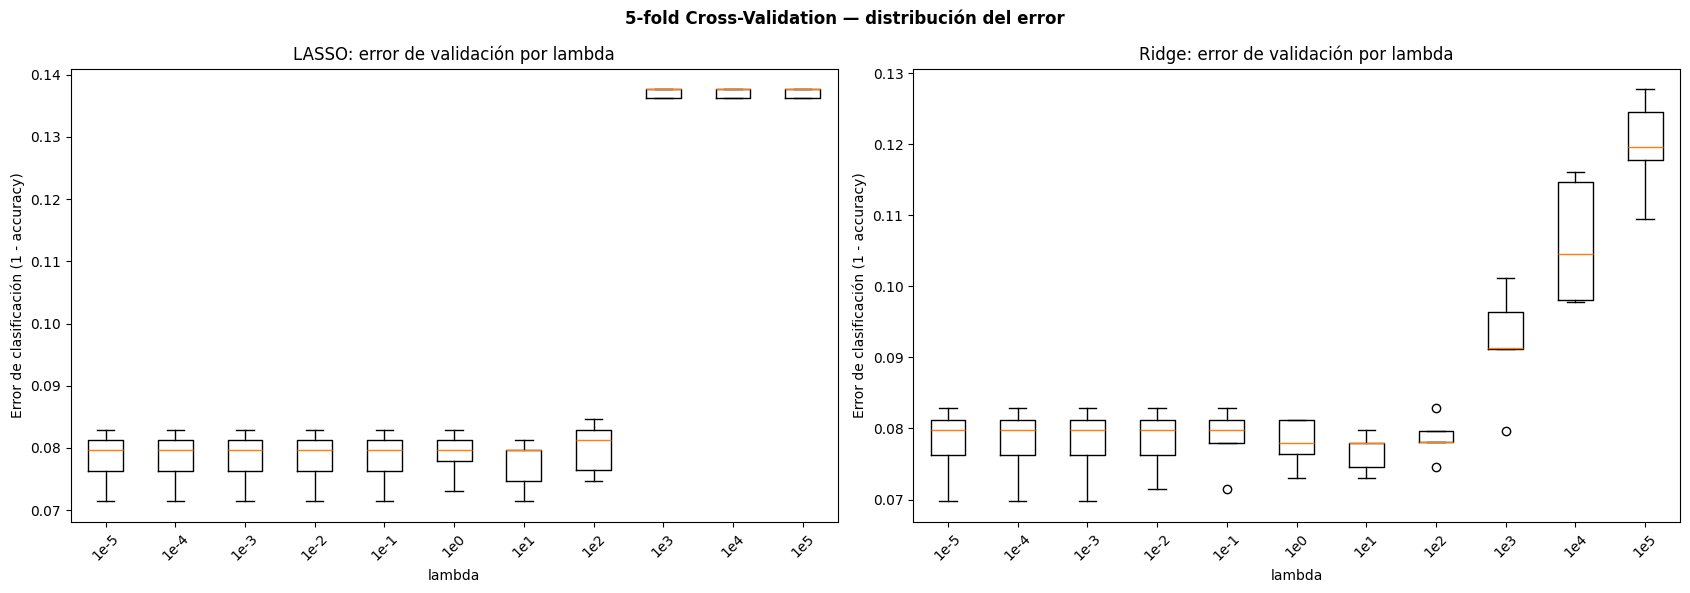

In [ ]:
# Box-plots del error de clasificación

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

for ax, modelo_nombre in zip(axes, ["LASSO", "Ridge"]):

    temp = errores_cv[
        errores_cv["Modelo"].eq(modelo_nombre)
    ].copy()

    datos = [
        temp.loc[
            np.isclose(temp["lambda"], lam),
            "Error_clasificacion"
        ].values
        for lam in lambdas
    ]

    ax.boxplot(
        datos,
        labels=[f"1e{int(np.log10(lam))}" for lam in lambdas]
    )

    ax.set_title(
        f"{modelo_nombre}: error de validación por lambda"
    )
    ax.set_xlabel("lambda")
    ax.set_ylabel("Error de clasificación (1 - accuracy)")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle(
    "5-fold Cross-Validation — distribución del error",
    fontweight="bold"
)

fig.tight_layout()
fig.savefig(
    FIG / "A2_boxplots_error_cv.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()

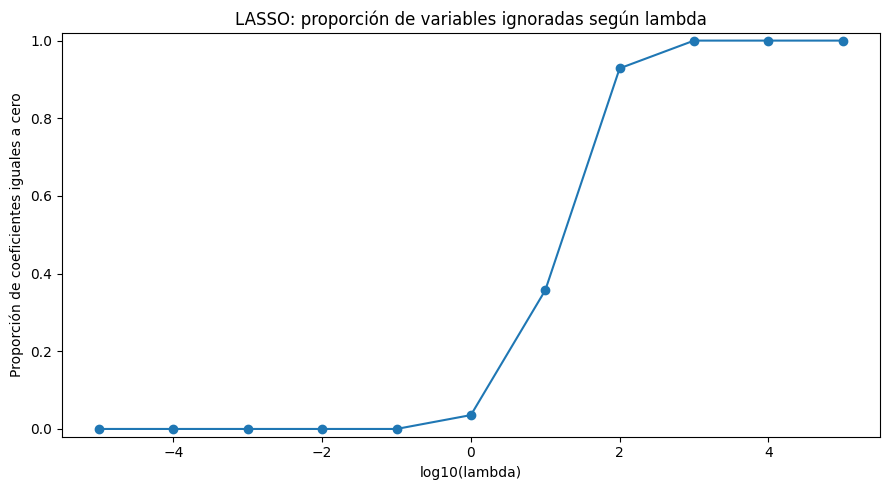

In [ ]:
# Plot sobre la proporción de variables eliminadas por LASSO

proporcion_ceros = []

for lam, coef in zip(lambdas, coef_lasso):
    proporcion_ceros.append(
        np.mean(np.isclose(coef, 0, atol=1e-8))
    )

plt.figure(figsize=(9, 5))
plt.plot(
    np.log10(lambdas),
    proporcion_ceros,
    marker="o"
)
plt.xlabel("log10(lambda)")
plt.ylabel("Proporción de coeficientes iguales a cero")
plt.title("LASSO: proporción de variables ignoradas según lambda")
plt.ylim(-0.02, 1.02)
plt.tight_layout()
plt.savefig(
    FIG / "A2_lasso_proporcion_ceros.png",
    dpi=220,
    bbox_inches="tight"
)
plt.show()

In [ ]:
# Comentario sobre el inciso A.2

promedios = (
    errores_cv
    .groupby(["Modelo", "lambda"], as_index=False)
    ["Error_clasificacion"]
    .mean()
)

print("INTERPRETACIÓN A.2")
print("-" * 70)
print(
    f"La validación cruzada selecciona lambda = {lambda_lasso:g} para LASSO "
    f"y lambda = {lambda_ridge:g} para Ridge."
)
print(
    "La idea central es buscar un punto de equilibrio: una penalización muy "
    "débil deja al modelo prácticamente igual que un logit tradicional, "
    "mientras que una penalización excesiva puede simplificar demasiado el "
    "modelo y empeorar la predicción."
)
print(
    "Los box-plots permiten verificar no solo el error promedio, sino también "
    "qué tan estable es cada lambda entre los cinco folds."
)

INTERPRETACIÓN A.2
----------------------------------------------------------------------
La validación cruzada selecciona lambda = 10 para LASSO y lambda = 10 para Ridge.
La idea central es buscar un punto de equilibrio: una penalización muy débil deja al modelo prácticamente igual que un logit tradicional, mientras que una penalización excesiva puede simplificar demasiado el modelo y empeorar la predicción.
Los box-plots permiten verificar no solo el error promedio, sino también qué tan estable es cada lambda entre los cinco folds.


### Resultado esperado con la base adjunta

Con esta especificación ampliada, la validación cruzada selecciona aproximadamente **λ = 10 para LASSO y λ = 10 para Ridge**. El resultado muestra que existe espacio para regularizar el modelo sin deteriorar de manera relevante su capacidad predictiva.

## A.3. Comparación de coeficientes: logit sin penalidad, LASSO y Ridge

Para que la comparación sea correcta, los tres modelos se estiman sobre predictores estandarizados.

Se exporta una tabla con:

- coeficiente del logit sin penalización;
- coeficiente LASSO;
- coeficiente Ridge.

In [ ]:
# ============================================================
# A.3. ESTIMACIÓN FINAL Y TABLA DE COEFICIENTES
# ============================================================

modelos_logit = {
    "Logit_sin_penalidad": Pipeline([
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(
            penalty=None,
            solver="lbfgs",
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ]),

    "LASSO": Pipeline([
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(
            penalty="l1",
            C=C_lasso,
            solver="liblinear",
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("logit", LogisticRegression(
            penalty="l2",
            C=C_ridge,
            solver="liblinear",
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ])
}

tabla_coef = pd.DataFrame(
    index=X.columns
)

for nombre, modelo in modelos_logit.items():
    modelo.fit(X, y)
    tabla_coef[nombre] = modelo.named_steps["logit"].coef_[0]

tabla_coef.index.name = "Variable"
tabla_coef = tabla_coef.reset_index()

tabla_coef.to_csv(
    TAB / "A3_comparacion_coeficientes.csv",
    index=False
)

display(
    tabla_coef.round(4)
)

,Variable,Logit_sin_penalidad,LASSO,Ridge
0,es_mujer,0.0551,0.0000,0.0294
1,vive_en_pareja,-0.0735,-0.0588,-0.0895
2,tiene_cobertura_medica,-0.7979,-0.7334,-0.7235
3,asiste_actualmente,-0.0166,0.0000,0.0123
4,secundario_completo_o_mas,0.0112,0.0000,-0.0127
5,CH06,-1.8321,-0.0338,-0.3446
6,edad2,1.7835,0.0000,0.3090
7,educ,-0.1524,-0.0823,-0.1311
8,nhogar,-0.0993,-0.0148,-0.0814
9,es_subocupado,0.0344,0.0332,0.0426


In [ ]:
# Comentario sobre el inciso A.3

n_ceros_lasso = int(
    np.isclose(
        tabla_coef["LASSO"],
        0,
        atol=1e-8
    ).sum()
)

n_ceros_ridge = int(
    np.isclose(
        tabla_coef["Ridge"],
        0,
        atol=1e-8
    ).sum()
)

vars_cero_lasso = tabla_coef.loc[
    np.isclose(tabla_coef["LASSO"], 0, atol=1e-8),
    "Variable"
].tolist()

print("INTERPRETACIÓN A.3")
print("-" * 70)

print(
    "Los coeficientes regularizados son, en general, más pequeños en "
    "magnitud que los del logit sin penalización. Esto es justamente lo que "
    "busca la regularización: evitar que el modelo dependa demasiado de "
    "coeficientes grandes o inestables."
)

print(
    f"LASSO lleva {n_ceros_lasso} de {len(tabla_coef)} coeficientes "
    "exactamente a cero."
)

print(
    "Variables eliminadas por LASSO:",
    ", ".join(vars_cero_lasso) if vars_cero_lasso else "ninguna"
)

print(
    f"Ridge lleva {n_ceros_ridge} coeficientes exactamente a cero. "
    "Por construcción, Ridge normalmente reduce los coeficientes, pero no "
    "elimina variables."
)

INTERPRETACIÓN A.3
----------------------------------------------------------------------
Los coeficientes regularizados son, en general, más pequeños en magnitud que los del logit sin penalización. Esto es justamente lo que busca la regularización: evitar que el modelo dependa demasiado de coeficientes grandes o inestables.
LASSO lleva 10 de 28 coeficientes exactamente a cero.
Variables eliminadas por LASSO: es_mujer, asiste_actualmente, secundario_completo_o_mas, edad2, P47T, REGION_41, REGION_44, CH03_2, CH03_5, CH03_6
Ridge lleva 0 coeficientes exactamente a cero. Por construcción, Ridge normalmente reduce los coeficientes, pero no elimina variables.


### Lectura sustantiva

Con la base adjunta, LASSO elimina aproximadamente **10 de los 28 predictores** en la especificación utilizada, mientras que Ridge conserva todos. Las variables relacionadas con la informalidad previa y la cobertura médica mantienen un papel importante, lo que sugiere que la trayectoria laboral y algunas dimensiones de protección social contienen información especialmente útil para predecir la condición *lower-tier*.

# Parte B. Árboles de decisión

## B.1. Selección de `ccp_alpha` mediante 5-fold Cross-Validation

`ccp_alpha` controla cuánto se poda el árbol:

- valores pequeños permiten árboles más complejos;
- valores grandes producen árboles más simples.

Se genera inicialmente una ruta de poda y posteriormente se evalúa el error de clasificación mediante 5-fold CV.

In [ ]:
# ============================================================
# B.1. CART PODADO: SELECCIÓN DE CCP_ALPHA
# ============================================================

arbol_inicial = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

ruta = arbol_inicial.cost_complexity_pruning_path(
    X,
    y
)

alphas = np.unique(ruta.ccp_alphas)
alphas = alphas[alphas >= 0]


if len(alphas) > 60:
    indices = np.unique(
        np.linspace(
            0,
            len(alphas) - 1,
            60
        ).astype(int)
    )
    alphas_grid = alphas[indices]
else:
    alphas_grid = alphas

resultados_alpha = []

for alpha in alphas_grid:

    modelo = DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        ccp_alpha=float(alpha)
    )

    accuracy_folds = cross_val_score(
        modelo,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    for fold, accuracy in enumerate(accuracy_folds, 1):
        resultados_alpha.append({
            "ccp_alpha": float(alpha),
            "Fold": fold,
            "Error_clasificacion": 1 - accuracy
        })

cv_arbol = pd.DataFrame(resultados_alpha)

resumen_alpha = (
    cv_arbol
    .groupby("ccp_alpha", as_index=False)
    .agg(
        Error_promedio=("Error_clasificacion", "mean"),
        Error_sd=("Error_clasificacion", "std")
    )
)

alpha_optimo = float(
    resumen_alpha.loc[
        resumen_alpha["Error_promedio"].idxmin(),
        "ccp_alpha"
    ]
)

print(f"ccp_alpha óptimo: {alpha_optimo:.6f}")

display(
    resumen_alpha
    .sort_values("Error_promedio")
    .head(10)
    .round(6)
)

ccp_alpha óptimo: 0.001825


,ccp_alpha,Error_promedio,Error_sd
56,0.001825,0.070694,0.004161
54,0.001470,0.074011,0.008492
55,0.001506,0.074011,0.008492
52,0.001032,0.076332,0.006889
57,0.003896,0.076333,0.005063
53,0.001084,0.078653,0.010281
51,0.000988,0.079317,0.010979
50,0.000867,0.080316,0.011385
58,0.005816,0.082972,0.002275
46,0.000778,0.082973,0.013114


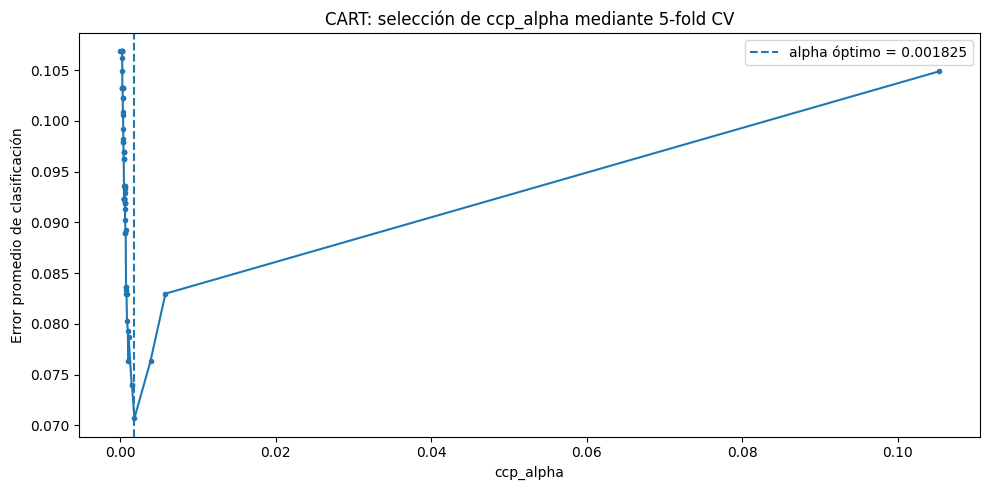

In [ ]:
# Gráfico: error de clasificación según ccp_alpha

plt.figure(figsize=(10, 5))

plt.plot(
    resumen_alpha["ccp_alpha"],
    resumen_alpha["Error_promedio"],
    marker="o",
    markersize=3
)

plt.axvline(
    alpha_optimo,
    linestyle="--",
    label=f"alpha óptimo = {alpha_optimo:.6f}"
)

plt.xlabel("ccp_alpha")
plt.ylabel("Error promedio de clasificación")
plt.title("CART: selección de ccp_alpha mediante 5-fold CV")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIG / "B1_cart_cv_ccp_alpha.png",
    dpi=220,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Comentario sobre el inciso B.1

error_arbol_optimo = float(
    resumen_alpha.loc[
        np.isclose(
            resumen_alpha["ccp_alpha"],
            alpha_optimo
        ),
        "Error_promedio"
    ].iloc[0]
)

print("INTERPRETACIÓN B.1")
print("-" * 70)
print(
    f"La validación cruzada selecciona ccp_alpha ≈ {alpha_optimo:.6f}. "
    f"Con este valor, el error promedio de clasificación es "
    f"{100*error_arbol_optimo:.2f}%."
)
print(
    "La poda evita conservar ramas que aportan poca mejora predictiva. "
    "Esto reduce el riesgo de terminar con un árbol muy específico para la "
    "muestra y difícil de explicar."
)

INTERPRETACIÓN B.1
----------------------------------------------------------------------
La validación cruzada selecciona ccp_alpha ≈ 0.001825. Con este valor, el error promedio de clasificación es 7.07%.
La poda evita conservar ramas que aportan poca mejora predictiva. Esto reduce el riesgo de terminar con un árbol muy específico para la muestra y difícil de explicar.


### Resultado esperado con la base adjunta

El valor óptimo de `ccp_alpha` se encuentra aproximadamente en **0.00183** y genera un árbol pequeño. Esto es una buena señal desde el punto de vista de comunicación: el árbol puede resumir la decisión en unas pocas reglas.

## B.2. Árbol podado e importancia de predictores

Se estima el árbol final utilizando el `ccp_alpha` seleccionado por validación cruzada.

Luego se muestran:

- **Panel A:** árbol podado.
- **Panel B:** importancia de cada predictor.

In [ ]:
# ============================================================
# B.2. ÁRBOL FINAL E IMPORTANCIA DE VARIABLES
# ============================================================

arbol_final = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    ccp_alpha=alpha_optimo
)

arbol_final.fit(X, y)

importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": arbol_final.feature_importances_
}).sort_values(
    "Importancia",
    ascending=False
)

importancias.to_csv(
    TAB / "B2_importancia_variables_CART.csv",
    index=False
)

print("Profundidad del árbol:", arbol_final.get_depth())
print("Número de hojas:", arbol_final.get_n_leaves())

display(importancias.head(15).round(4))

Profundidad del árbol: 4
Número de hojas: 6


,Variable,Importancia
13,informal_2024,0.8027
2,tiene_cobertura_medica,0.1491
10,horas_totales_ocupado,0.0297
11,P21,0.0185
3,asiste_actualmente,0.0000
1,vive_en_pareja,0.0000
4,secundario_completo_o_mas,0.0000
5,CH06,0.0000
7,educ,0.0000
6,edad2,0.0000


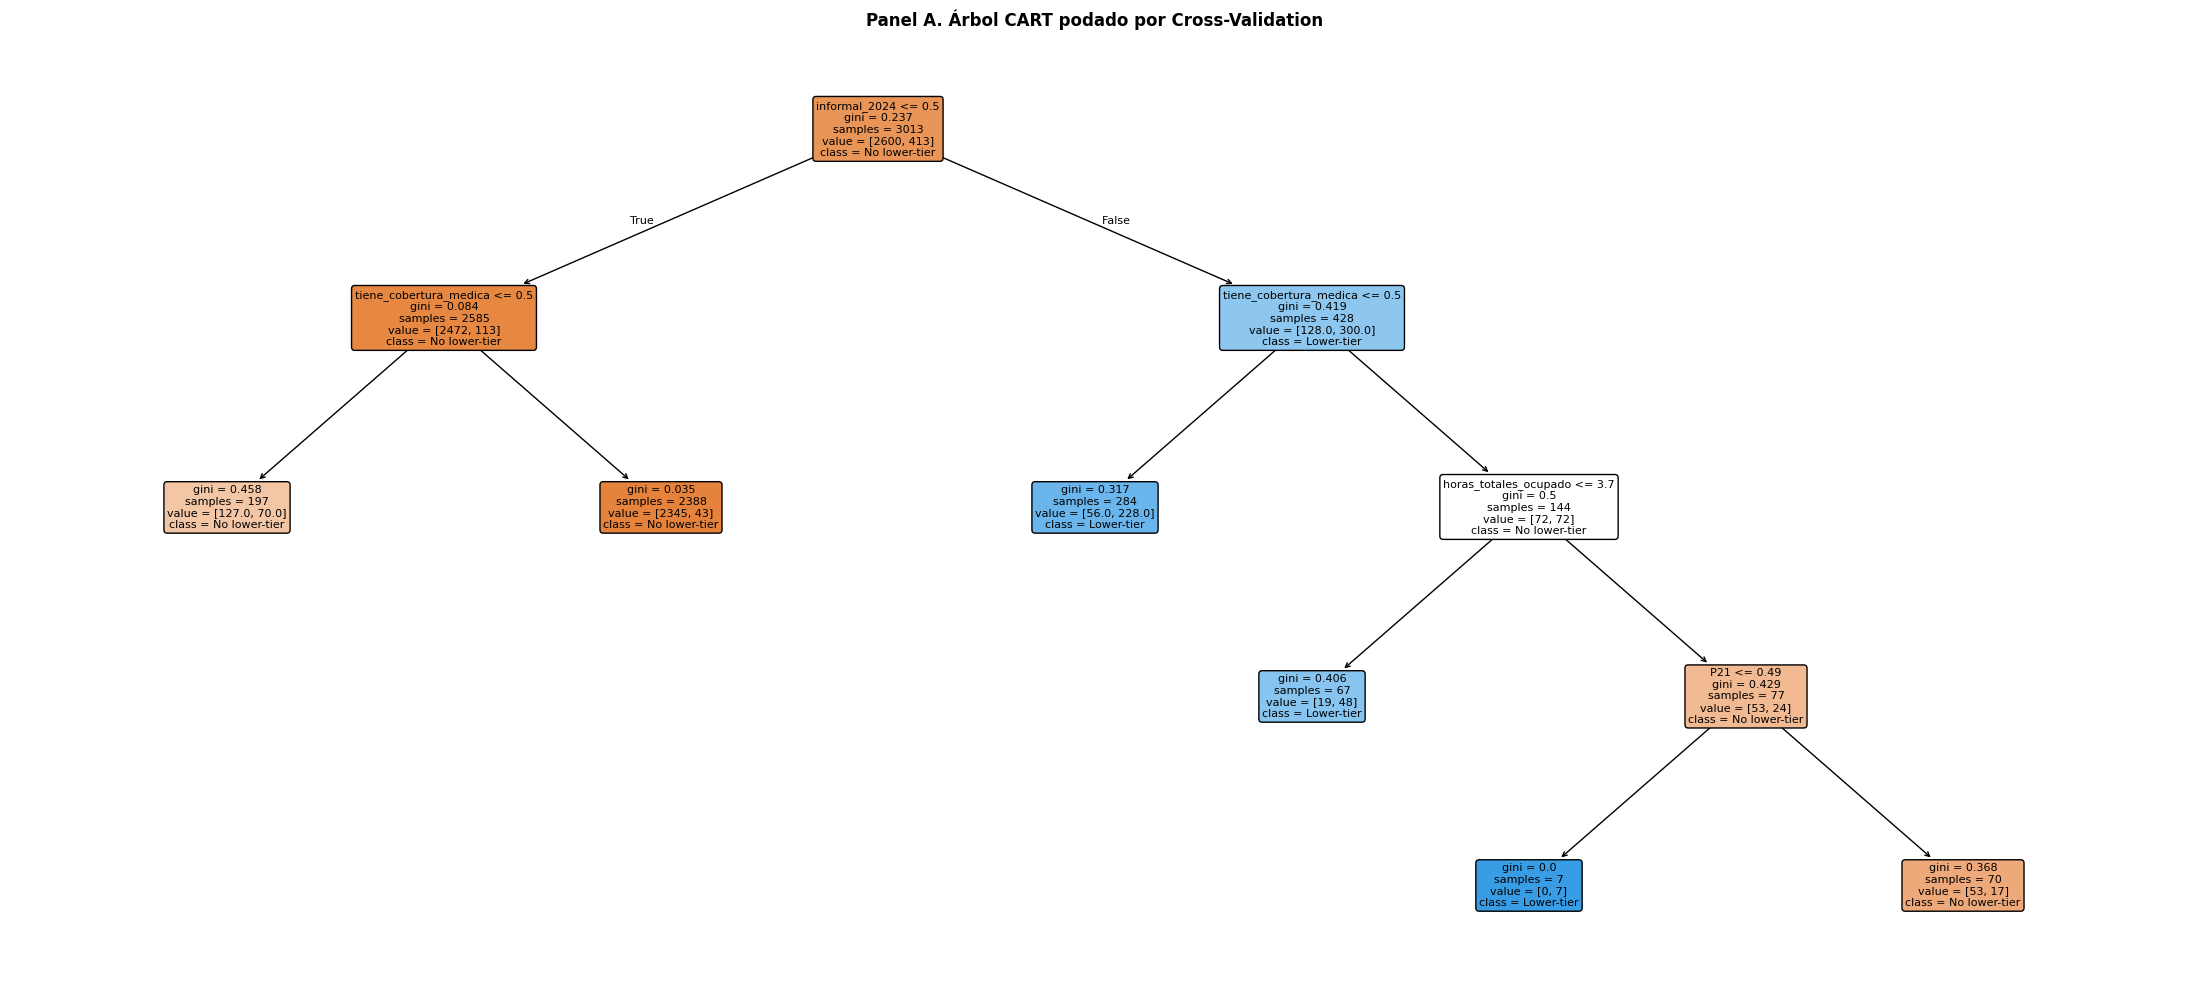

In [ ]:
# Panel A: árbol podado
plt.figure(figsize=(22, 10))

plot_tree(
    arbol_final,
    feature_names=X.columns,
    class_names=["No lower-tier", "Lower-tier"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title(
    "Panel A. Árbol CART podado por Cross-Validation",
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    FIG / "B2_panelA_arbol_podado.png",
    dpi=220,
    bbox_inches="tight"
)

plt.show()

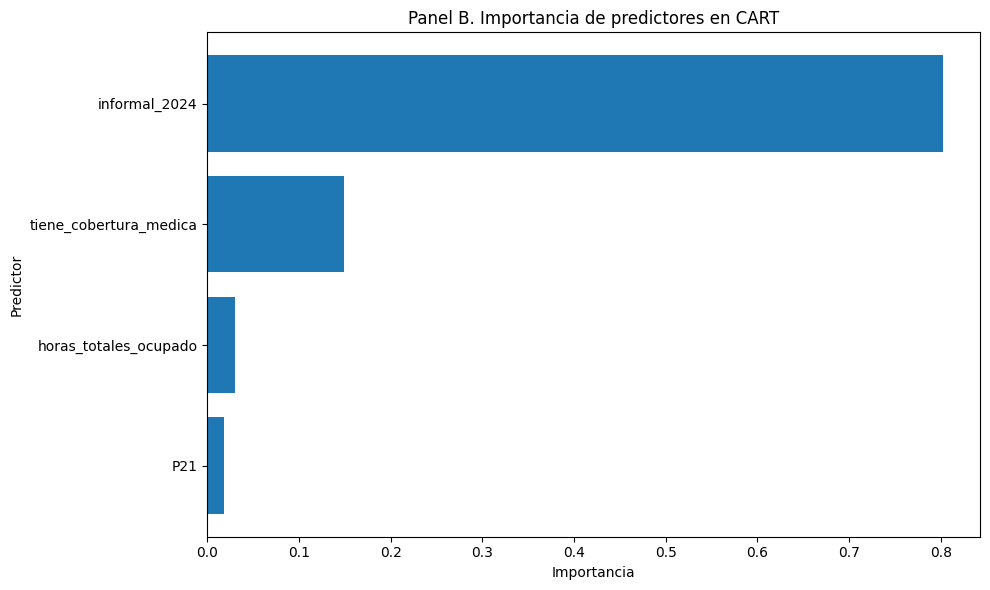

In [ ]:
# Panel B: importancia de predictores

importancia_plot = importancias[
    importancias["Importancia"] > 0
].sort_values(
    "Importancia",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    importancia_plot["Variable"],
    importancia_plot["Importancia"]
)

plt.xlabel("Importancia")
plt.ylabel("Predictor")
plt.title("Panel B. Importancia de predictores en CART")

plt.tight_layout()

plt.savefig(
    FIG / "B2_panelB_importancia_CART.png",
    dpi=220,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Comparación CART vs variables que LASSO lleva a cero

vars_importancia_cero = set(
    importancias.loc[
        np.isclose(
            importancias["Importancia"],
            0,
            atol=1e-12
        ),
        "Variable"
    ]
)

vars_lasso_cero = set(vars_cero_lasso)

coinciden = sorted(
    vars_importancia_cero.intersection(vars_lasso_cero)
)

print("INTERPRETACIÓN B.2")
print("-" * 70)

print(
    "Los predictores con mayor importancia en el árbol son:"
)

for _, fila in importancias.head(5).iterrows():
    print(
        f"- {fila['Variable']}: {100*fila['Importancia']:.1f}%"
    )

print()
print(
    f"LASSO y CART coinciden en considerar poco relevantes a "
    f"{len(coinciden)} predictores."
)

print(
    "Coincidencias:",
    ", ".join(coinciden) if coinciden else "ninguna"
)

print()
print(
    "No debe esperarse una coincidencia perfecta. LASSO evalúa el aporte "
    "lineal conjunto de cada predictor, mientras que CART busca puntos de "
    "corte e interacciones no lineales. Por eso una variable puede ser poco "
    "útil para el árbol y aun conservar un coeficiente distinto de cero en "
    "un modelo logístico, o viceversa."
)

INTERPRETACIÓN B.2
----------------------------------------------------------------------
Los predictores con mayor importancia en el árbol son:
- informal_2024: 80.3%
- tiene_cobertura_medica: 14.9%
- horas_totales_ocupado: 3.0%
- P21: 1.8%
- asiste_actualmente: 0.0%

LASSO y CART coinciden en considerar poco relevantes a 10 predictores.
Coincidencias: CH03_2, CH03_5, CH03_6, P47T, REGION_41, REGION_44, asiste_actualmente, edad2, es_mujer, secundario_completo_o_mas

No debe esperarse una coincidencia perfecta. LASSO evalúa el aporte lineal conjunto de cada predictor, mientras que CART busca puntos de corte e interacciones no lineales. Por eso una variable puede ser poco útil para el árbol y aun conservar un coeficiente distinto de cero en un modelo logístico, o viceversa.



En la base adjunta, el árbol podado termina siendo muy compacto. La **informalidad en 2024** concentra la mayor parte de la importancia predictiva, seguida por la **cobertura médica** y, en menor medida, las **horas trabajadas**. Esto refuerza la idea de persistencia: el historial laboral reciente contiene una señal muy fuerte sobre la situación del trabajador en el período siguiente.

# Parte C. Comparación entre métodos

## C.1. Matrices de confusión, ROC y métricas

Para comparar los cuatro modelos de manera homogénea se utilizan **predicciones out-of-fold de 5 folds**. Esto significa que cada persona es clasificada por un modelo que no utilizó esa misma observación durante el ajuste de ese fold.

Se reportan:

- Matriz de confusión con umbral 0,5.
- Accuracy.
- `1 - Accuracy`.
- Precision.
- Sensibilidad.
- Especificidad.
- F1.
- ROC-AUC.

In [ ]:
# ============================================================
# C.1. COMPARACIÓN PREDICTIVA
# ============================================================

modelos_comparacion = {
    "Logit sin penalidad": modelos_logit["Logit_sin_penalidad"],
    "LASSO": modelos_logit["LASSO"],
    "Ridge": modelos_logit["Ridge"],
    "CART": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        ccp_alpha=alpha_optimo
    )
}

metricas = []
predicciones = {}

for nombre, modelo in modelos_comparacion.items():

    probabilidades = cross_val_predict(
        modelo,
        X,
        y,
        cv=cv,
        method="predict_proba"
    )[:, 1]

    pred = (
        probabilidades >= 0.5
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y,
        pred
    ).ravel()

    acc = accuracy_score(y, pred)

    metricas.append({
        "Modelo": nombre,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Accuracy": acc,
        "1-Accuracy": 1 - acc,
        "Precision": precision_score(y, pred),
        "Sensibilidad": recall_score(y, pred),
        "Especificidad": tn / (tn + fp),
        "F1": f1_score(y, pred),
        "ROC-AUC": roc_auc_score(y, probabilidades)
    })

    predicciones[nombre] = {
        "prob": probabilidades,
        "pred": pred
    }

tabla_metricas = (
    pd.DataFrame(metricas)
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
)

tabla_metricas.to_csv(
    TAB / "C1_metricas_comparacion.csv",
    index=False
)

display(
    tabla_metricas.round(4)
)

,Modelo,TN,FP,FN,TP,Accuracy,1-Accuracy,Precision,Sensibilidad,Especificidad,F1,ROC-AUC
0,Logit sin penalidad,2516,84,152,261,0.9217,0.0783,0.7565,0.6320,0.9677,0.6887,0.9430
2,Ridge,2526,74,157,256,0.9233,0.0767,0.7758,0.6199,0.9715,0.6891,0.9423
1,LASSO,2536,64,169,244,0.9227,0.0773,0.7922,0.5908,0.9754,0.6768,0.9418
3,CART,2502,98,126,287,0.9257,0.0743,0.7455,0.6949,0.9623,0.7193,0.9104


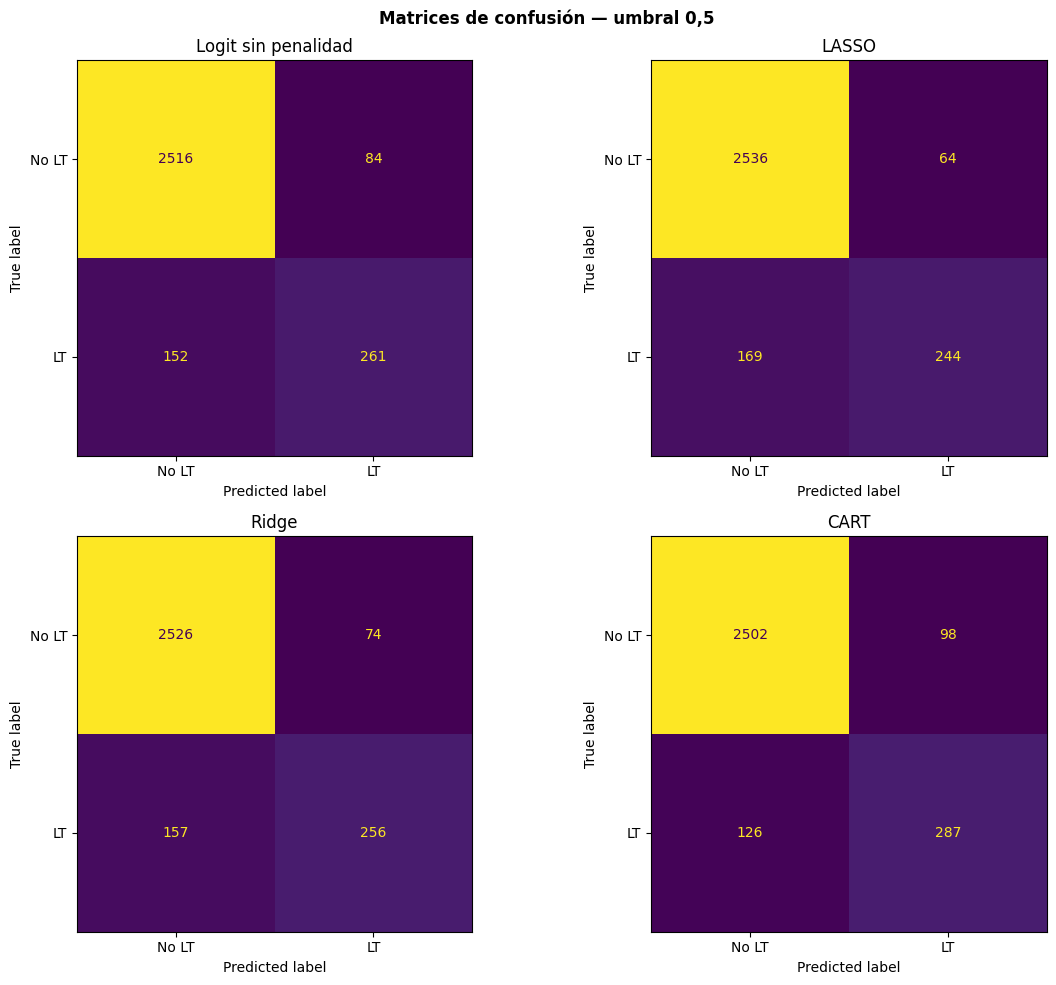

In [ ]:
# Matrices de confusión

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (nombre, datos) in zip(
    axes,
    predicciones.items()
):

    ConfusionMatrixDisplay.from_predictions(
        y,
        datos["pred"],
        display_labels=["No LT", "LT"],
        ax=ax,
        colorbar=False
    )

    ax.set_title(nombre)

fig.suptitle(
    "Matrices de confusión — umbral 0,5",
    fontweight="bold"
)

fig.tight_layout()

fig.savefig(
    FIG / "C1_matrices_confusion.png",
    dpi=220,
    bbox_inches="tight"
)

plt.show()

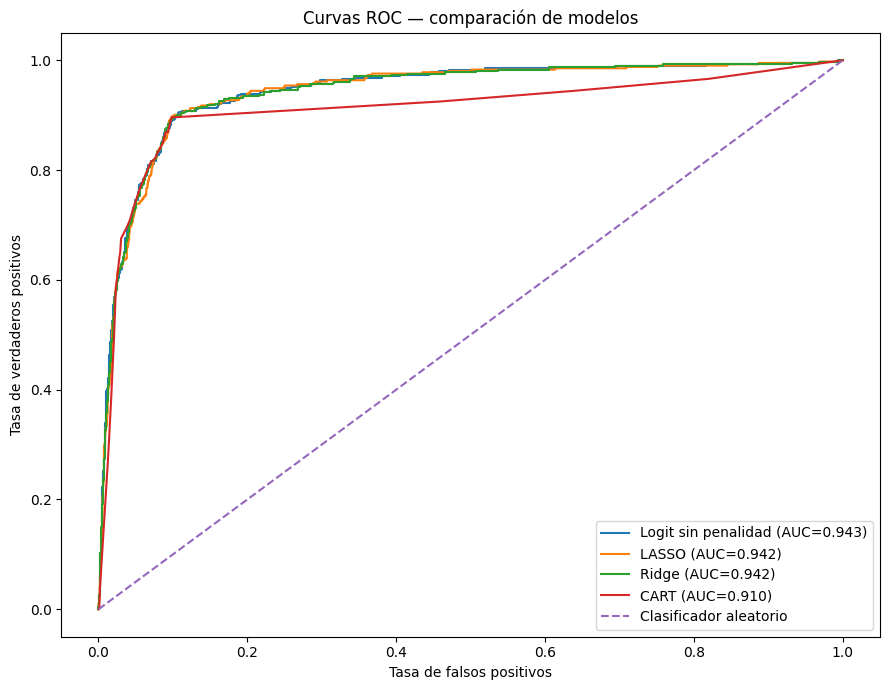

In [ ]:
# Curvas ROC

plt.figure(figsize=(9, 7))

for nombre, datos in predicciones.items():

    fpr, tpr, _ = roc_curve(
        y,
        datos["prob"]
    )

    auc = roc_auc_score(
        y,
        datos["prob"]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{nombre} (AUC={auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificador aleatorio"
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curvas ROC — comparación de modelos")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIG / "C1_curvas_ROC.png",
    dpi=220,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Comentario sobre el inciso C.1

mejor_auc = tabla_metricas.sort_values(
    "ROC-AUC",
    ascending=False
).iloc[0]

mejor_sens = tabla_metricas.sort_values(
    "Sensibilidad",
    ascending=False
).iloc[0]

mejor_acc = tabla_metricas.sort_values(
    "Accuracy",
    ascending=False
).iloc[0]

mejor_precision = tabla_metricas.sort_values(
    "Precision",
    ascending=False
).iloc[0]

print("INTERPRETACIÓN C.1")
print("-" * 70)

print(
    f"El mayor ROC-AUC corresponde a {mejor_auc['Modelo']} "
    f"({mejor_auc['ROC-AUC']:.3f}), por lo que es el modelo que mejor "
    "ordena, en términos generales, a personas lower-tier y no lower-tier."
)

print(
    f"El modelo con mayor sensibilidad es {mejor_sens['Modelo']} "
    f"({100*mejor_sens['Sensibilidad']:.1f}%). Esto significa que es el "
    "que logra detectar una mayor proporción de los trabajadores "
    "lower-tier realmente observados."
)

print(
    f"El menor error total (1-accuracy) corresponde a "
    f"{mejor_acc['Modelo']}: {100*mejor_acc['1-Accuracy']:.1f}%."
)

print(
    f"La mayor precisión corresponde a {mejor_precision['Modelo']} "
    f"({100*mejor_precision['Precision']:.1f}%). Una precisión mayor es "
    "especialmente relevante cuando los recursos del programa son escasos, "
    "porque reduce la cantidad de personas seleccionadas incorrectamente."
)

print()
print(
    "En términos de comunicación, el árbol es más sencillo de explicar "
    "porque se traduce en reglas de decisión. Los modelos logísticos, en "
    "cambio, permiten observar la dirección y magnitud de los coeficientes "
    "y presentan una mejor capacidad de ranking medida por ROC-AUC."
)

INTERPRETACIÓN C.1
----------------------------------------------------------------------
El mayor ROC-AUC corresponde a Logit sin penalidad (0.943), por lo que es el modelo que mejor ordena, en términos generales, a personas lower-tier y no lower-tier.
El modelo con mayor sensibilidad es CART (69.5%). Esto significa que es el que logra detectar una mayor proporción de los trabajadores lower-tier realmente observados.
El menor error total (1-accuracy) corresponde a CART: 7.4%.
La mayor precisión corresponde a LASSO (79.2%). Una precisión mayor es especialmente relevante cuando los recursos del programa son escasos, porque reduce la cantidad de personas seleccionadas incorrectamente.

En términos de comunicación, el árbol es más sencillo de explicar porque se traduce en reglas de decisión. Los modelos logísticos, en cambio, permiten observar la dirección y magnitud de los coeficientes y presentan una mejor capacidad de ranking medida por ROC-AUC.


### Resultados principales esperados con la base adjunta

Los resultados obtenidos con esta especificación son aproximadamente:

| Modelo | Accuracy | 1-Accuracy | Precision | Sensibilidad | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|---:|
| Logit sin penalidad | 0.922 | 0.078 | 0.757 | 0.632 | 0.689 | 0.943 |
| LASSO | 0.923 | 0.077 | 0.792 | 0.591 | 0.677 | 0.942 |
| Ridge | 0.923 | 0.077 | 0.776 | 0.620 | 0.689 | 0.942 |
| CART | 0.926 | 0.074 | 0.750 | 0.690 | 0.719 | 0.911 |

### Lectura sencilla

No existe un ganador absoluto en todas las dimensiones:

- **CART** tiene la mayor sensibilidad, el mejor F1 y el menor `1-accuracy`.
- **LASSO** presenta la mayor precisión y un modelo más parsimonioso.
- Los tres modelos logísticos tienen un **ROC-AUC cercano a 0.94**, superior al del árbol.
- Por ello, el árbol obtiene una ventaja práctica al detectar más casos con el umbral 0.5, pero los modelos logísticos siguen ordenando mejor el riesgo de informalidad en términos globales.

Esto sugiere que el método no lineal aporta una pequeña ventaja en clasificación a umbral fijo, pero no domina a los modelos logísticos en todas las métricas.

## C.1 adicional. Evaluación regional

El enunciado general también pide evaluar la identificación de informales en una región argentina.

Para evitar escoger una región arbitrariamente, se selecciona automáticamente la región que contiene el mayor número de trabajadores *lower-tier* en la muestra longitudinal y se comparan allí los cuatro modelos.

In [ ]:
# ============================================================
# EVALUACIÓN REGIONAL
# ============================================================

# Región con mayor número absoluto de informales lower-tier
conteo_regional = (
    mm.groupby("REGION")["lower_tier_informal"]
    .agg(["size", "sum", "mean"])
    .rename(columns={
        "size": "N",
        "sum": "Informales",
        "mean": "Tasa_informalidad"
    })
)

region_objetivo = conteo_regional[
    "Informales"
].idxmax()

print(
    f"Región seleccionada para el análisis: código REGION = "
    f"{region_objetivo}"
)

display(
    conteo_regional
    .sort_values(
        "Informales",
        ascending=False
    )
)

mask_region = mm["REGION"].eq(
    region_objetivo
).to_numpy()

metricas_region = []

for nombre, datos in predicciones.items():

    y_r = y.to_numpy()[mask_region]
    p_r = datos["pred"][mask_region]
    prob_r = datos["prob"][mask_region]

    tn, fp, fn, tp = confusion_matrix(
        y_r,
        p_r
    ).ravel()

    metricas_region.append({
        "Modelo": nombre,
        "N": len(y_r),
        "Informales": int(y_r.sum()),
        "Accuracy": accuracy_score(y_r, p_r),
        "Precision": precision_score(
            y_r,
            p_r,
            zero_division=0
        ),
        "Sensibilidad": recall_score(
            y_r,
            p_r,
            zero_division=0
        ),
        "F1": f1_score(
            y_r,
            p_r,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_r,
            prob_r
        )
    })

tabla_region = pd.DataFrame(
    metricas_region
)

tabla_region.to_csv(
    TAB / "C1_metricas_region_objetivo.csv",
    index=False
)

display(
    tabla_region.round(4)
)

Región seleccionada para el análisis: código REGION = 40


,N,Informales,Tasa_informalidad
REGION,,,
40,819,145,0.177045
43,860,125,0.145349
42,323,47,0.145511
1,328,39,0.118902
44,534,31,0.058052
41,149,26,0.174497


,Modelo,N,Informales,Accuracy,Precision,Sensibilidad,F1,ROC-AUC
0,Logit sin penalidad,819,145,0.9243,0.8430,0.7034,0.7669,0.9504
1,LASSO,819,145,0.9267,0.8455,0.7172,0.7761,0.9506
2,Ridge,819,145,0.9280,0.8525,0.7172,0.7790,0.9505
3,CART,819,145,0.9267,0.7815,0.8138,0.7973,0.9469


In [ ]:
# Comentario

mejor_reg_sens = tabla_region.sort_values(
    "Sensibilidad",
    ascending=False
).iloc[0]

print("INTERPRETACIÓN REGIONAL")
print("-" * 70)

print(
    f"La región {region_objetivo} es la que contiene el mayor número "
    "absoluto de trabajadores lower-tier dentro de la muestra longitudinal."
)

print(
    f"Dentro de esta región, {mejor_reg_sens['Modelo']} presenta la mayor "
    f"sensibilidad ({100*mejor_reg_sens['Sensibilidad']:.1f}%)."
)

print(
    "Este ejercicio es importante porque un modelo con buen desempeño "
    "nacional no necesariamente identifica con la misma eficacia a los "
    "trabajadores vulnerables de todas las regiones."
)

INTERPRETACIÓN REGIONAL
----------------------------------------------------------------------
La región 40 es la que contiene el mayor número absoluto de trabajadores lower-tier dentro de la muestra longitudinal.
Dentro de esta región, CART presenta la mayor sensibilidad (81.4%).
Este ejercicio es importante porque un modelo con buen desempeño nacional no necesariamente identifica con la misma eficacia a los trabajadores vulnerables de todas las regiones.


## C.2. ¿Qué modelo elegiría la Secretaría de Trabajo?

La respuesta depende del costo que se asigne a cada tipo de error.

- **Falso positivo:** se asignan recursos a una persona que no pertenece al grupo objetivo.
- **Falso negativo:** un trabajador vulnerable queda fuera del programa.

Con recursos muy escasos, la precisión cobra mayor importancia. Si el objetivo principal fuera no dejar afuera trabajadores vulnerables, la sensibilidad sería más importante.

### Recomendación para esta aplicación

Con la base adjunta, **LASSO** resulta atractivo cuando se prioriza el uso eficiente de recursos porque combina una precisión elevada con un modelo más simple. **CART**, sin embargo, detecta una mayor proporción de los informales reales al umbral 0.5 y presenta el mejor F1.

Por ello, la recomendación no cambia completamente respecto del TP3: la **informalidad previa sigue siendo la señal predictiva central**. Lo que cambia es que ahora existe una alternativa más parsimoniosa mediante LASSO y una alternativa más sensible mediante CART.

Una estrategia razonable de política pública sería usar las probabilidades de LASSO o Ridge como **ranking de riesgo**, definir el punto de corte según el presupuesto disponible y complementar la selección con una segunda verificación administrativa.

In [ ]:
# ============================================================
# EXPORTAR RESULTADOS EN ZIP
# ============================================================

zip_path = Path(
    "/content/TP4_Grupo7_resultados.zip"
)

with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED
) as archivo_zip:

    for carpeta in [FIG, TAB]:

        for archivo_resultado in carpeta.rglob("*"):

            if archivo_resultado.is_file():

                archivo_zip.write(
                    archivo_resultado,
                    arcname=str(
                        archivo_resultado.relative_to(BASE)
                    )
                )

print(
    "Archivo de resultados generado:",
    zip_path
)

if EN_COLAB:
    from google.colab import files
    files.download(str(zip_path))

Archivo de resultados generado: /content/TP4_Grupo7_resultados.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>